**Lab 5**

Develop a program to implement k-Nearest Neighbour algorithm to classify the randomly generated 100 values of x in the range of [0,1]. Perform the following based on dataset generated.
- Label the first 50 points {x1,……,x50} as follows: if (xi ≤ 0.5), then xi ∊ Class1, else xi ∊ Class1
- Classify the remaining points, x51,……,x100 using KNN. Perform this for k=1,2,3,4,5,20,30

In [8]:
# Import required packages
import matplotlib.pyplot as plt
import numpy as np

from collections import Counter

In [9]:
data = np.random.rand(100)
labels = ["Class1" if x <= 0.5 else "Class2" for x in data[:50]]

In [10]:
def euclidean_distance(x1, x2):
    return abs(x1 - x2)

In [ ]:
def knn_classifier(train_data, train_labels, test_point, k):
    distances = [
        (euclidean_distance(test_point, train_data[i]), train_labels[i])
        for i in range(len(train_data))
    ]
    distances.sort(key=lambda x: x[0])

    k_nearest_neighbors = distances[:k]
    k_nearest_labels = [label for _, label in k_nearest_neighbors]

    return Counter(k_nearest_labels).most_common(1)[0][0]

In [13]:
train_data = data[:50]
train_labels = labels

test_data = data[50:]
k_values = [1, 2, 3, 4, 5, 20, 30]

print("k-Nearest Neighbors Classification\n")
print(
    "Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)"
)
print("Testing dataset: Remaining 50 points to be classified\n")

results = {}

for k in k_values:
    print(f"Results for k = {k}:")
    classified_labels = [
        knn_classifier(train_data, train_labels, test_point, k)
        for test_point in test_data
    ]
    results[k] = classified_labels

    for i, label in enumerate(classified_labels, start=51):
        print(f"Point x{i} (value: {test_data[i - 51]:.4f}) is classified as {label}")
    print("\n")

print("Classification complete.")

k-Nearest Neighbors Classification

Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)
Testing dataset: Remaining 50 points to be classified

Results for k = 1:
Point x51 (value: 0.1216) is classified as Class1
Point x52 (value: 0.5569) is classified as Class2
Point x53 (value: 0.7117) is classified as Class2
Point x54 (value: 0.1640) is classified as Class1
Point x55 (value: 0.0509) is classified as Class1
Point x56 (value: 0.2504) is classified as Class1
Point x57 (value: 0.6609) is classified as Class2
Point x58 (value: 0.3437) is classified as Class1
Point x59 (value: 0.6188) is classified as Class2
Point x60 (value: 0.0816) is classified as Class1
Point x61 (value: 0.9961) is classified as Class2
Point x62 (value: 0.3625) is classified as Class1
Point x63 (value: 0.7937) is classified as Class2
Point x64 (value: 0.2367) is classified as Class1
Point x65 (value: 0.1538) is classified as Class1
Point x66 (value: 0.0060) is classified 

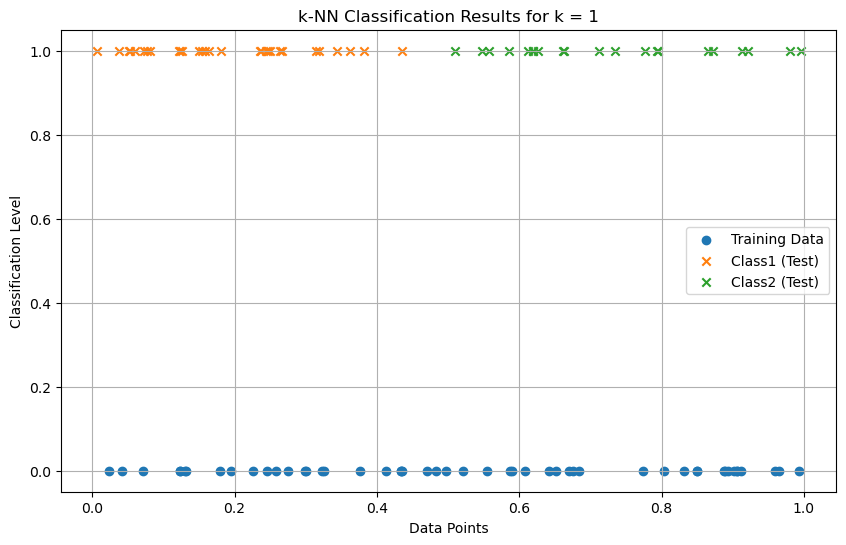

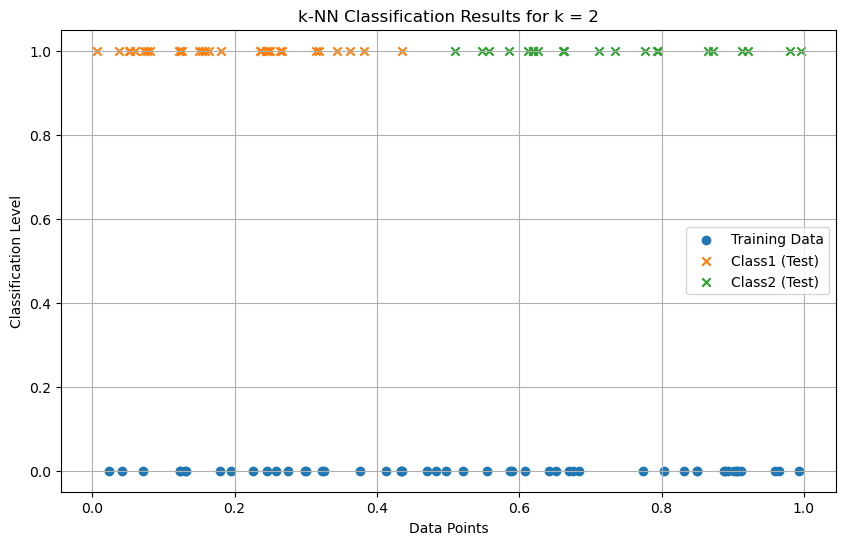

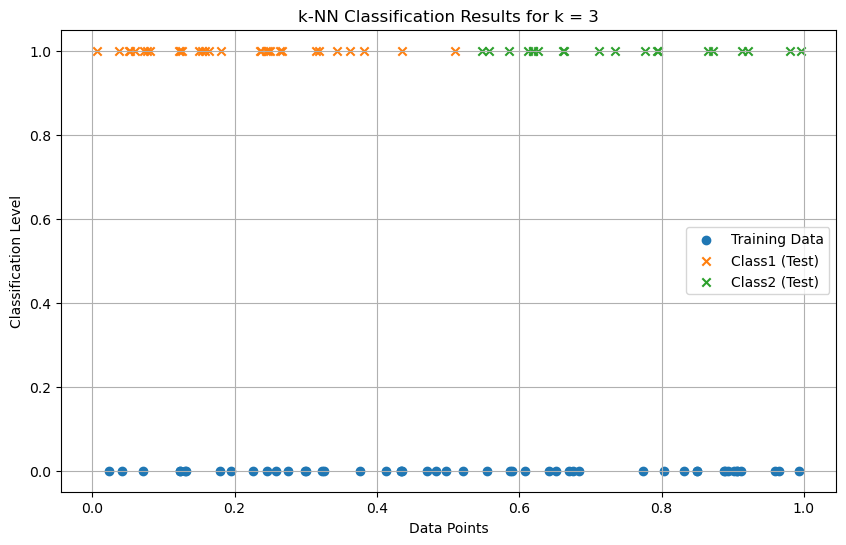

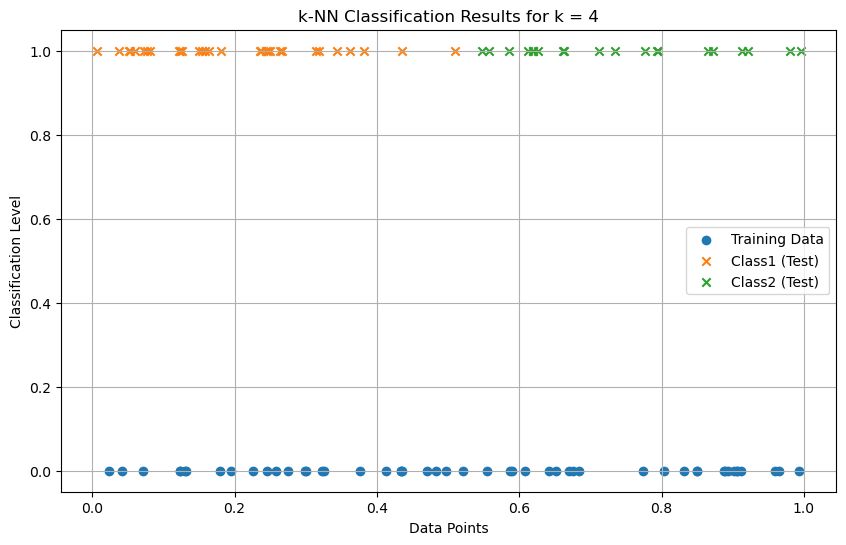

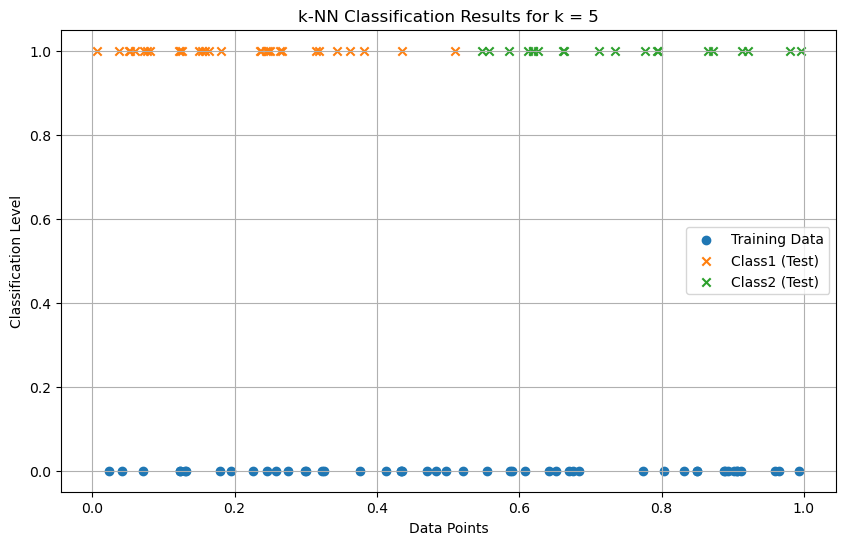

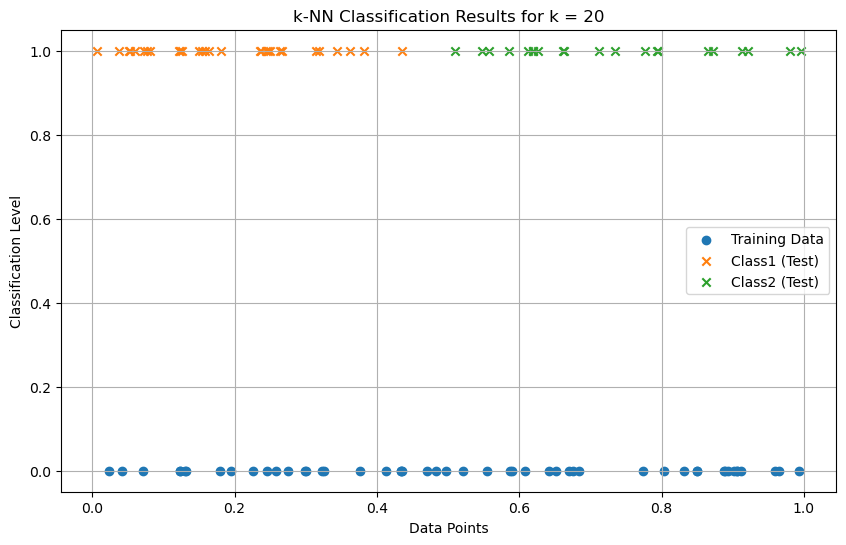

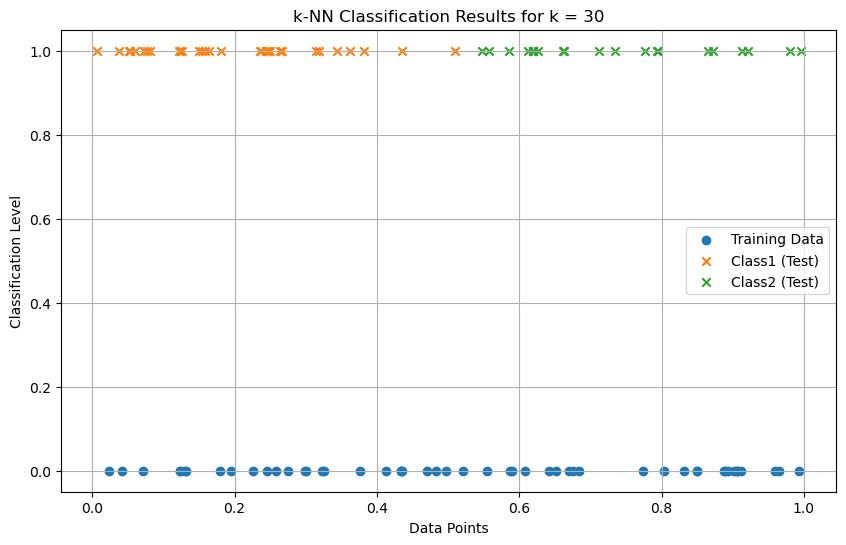

In [15]:
for k in k_values:
    classified_labels = results[k]
    class1_points = [
        test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class1"
    ]
    class2_points = [
        test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class2"
    ]

    plt.figure(figsize=(10, 6))
    plt.scatter(train_data, [0] * len(train_data), label="Training Data", marker="o")
    plt.scatter(
        class1_points, [1] * len(class1_points), label="Class1 (Test)", marker="x"
    )
    plt.scatter(
        class2_points, [1] * len(class2_points), label="Class2 (Test)", marker="x"
    )

    plt.title(f"k-NN Classification Results for k = {k}")
    plt.xlabel("Data Points")
    plt.ylabel("Classification Level")
    plt.legend()
    plt.grid(True)
    plt.show()